# Particle–field coupling with NGP

## Objective
The goal is to add particle motion and current deposition to the cylindrical FDTD solver while preserving the assignment constraints: nearest-grid-point (NGP) assignment/interpolation, magnetic-only particle push, and no fundamental change to the Maxwell solver.

## Numerical consistency
The same NGP rule is used both to gather the magnetic field at particle positions and to assign particle current density back to the grid. This ensures consistency between interpolation and deposition.

## Particle motion
Particle trajectories are advanced with a Boris rotation using only the azimuthal magnetic field $B_\theta$. The electric field is not used in the particle pusher, so particle motion remains independent of $E$, as required.

## Maxwell update
The electromagnetic fields are advanced with the original cylindrical Yee-FDTD update equations. Particle currents $J_r$ and $J_z$ enter only through the source terms already present in Ampere's law.

## Validation 1: single-particle orbit
A single particle is initialized in a uniform magnetic field. The trajectory in the $(r,z)$ plane is circular, showing the expected gyromotion under magnetic-only forcing.

## Validation 2: speed conservation
For magnetic-only motion, the Lorentz force does no work. The particle speed therefore remains constant throughout the simulation, confirming the correctness of the Boris rotation.

## Validation 3: gyro-radius scaling
The gyro-radius is measured for several magnetic field strengths. The numerical trend follows the expected inverse dependence on magnetic field magnitude, $r_g \propto 1/B$.

## Validation 4: spectral diagnostic
A space-time record of $E_z(z,t)$ is extracted from the PIC-FDTD run and transformed into $(k,\omega)$ space using a two-dimensional Fourier transform. This provides a qualitative dispersion diagnostic of wave activity in the coupled simulation.

## Interpretation
The first three tests validate the particle pusher and NGP coupling. The final $(k,\omega)$ figure is presented as a qualitative spectral diagnostic rather than a full physical verification of the dispersion relation.


=== Validation 1: single-particle orbit ===


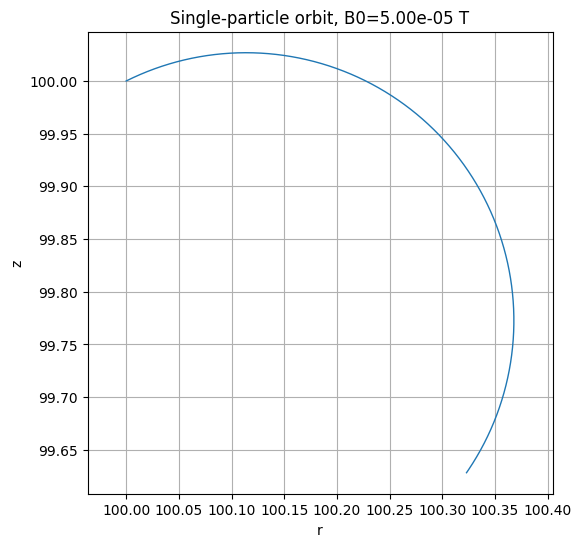

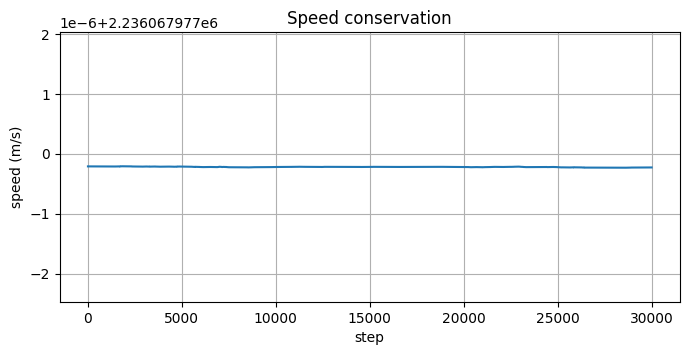

Initial speed: 2236067.9774997896
Final speed:   2236067.977499772
Relative change: -7.913502226117255e-15
v/c: 0.007458719917162791

=== Validation 2: gyro-radius scaling ===


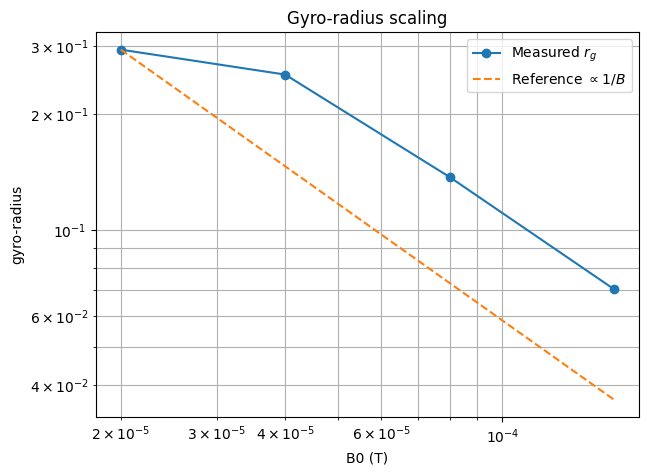


=== Validation 3: NGP staircase interpolation ===


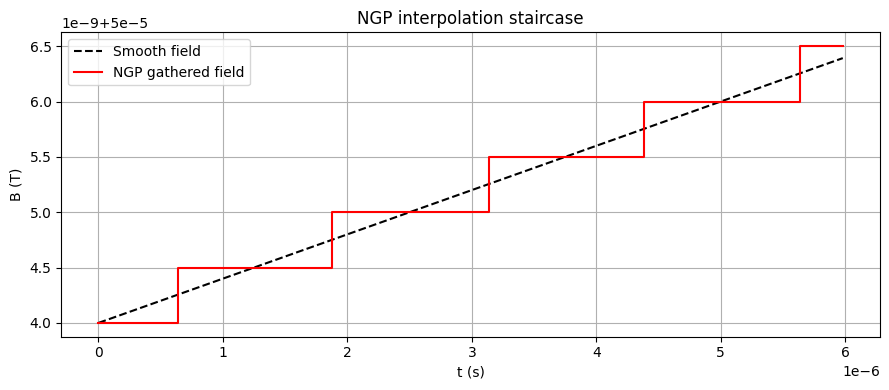


=== PIC dispersion run ===
Saved Ez_zt_pic.npy, t_hist_pic.npy, z_grid_pic.npy

=== Validation 4: omega-k from PIC-FDTD run ===


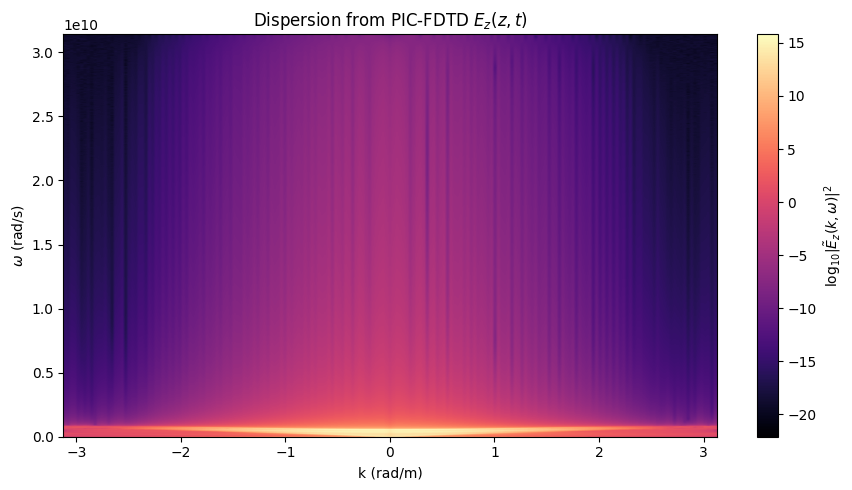

In [2]:

import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Physical constants
# ============================================================
c = 299792458.0
mu0 = 4.0 * np.pi * 1e-7
eps0 = 1.0 / (mu0 * c**2)

q = -1.602176634e-19
m = 9.10938356e-31

# ============================================================
# Shared helpers
# ============================================================
def ngp_index_rz(pr, pz, dr, dz, Nr, Nz):
    ir = np.rint(pr / dr).astype(int)
    iz = np.rint(pz / dz).astype(int)
    ir = np.clip(ir, 0, Nr)
    iz = np.clip(iz, 0, Nz)
    return ir, iz

def gather_Btheta_NGP(pr, pz, Btheta_grid, dr, dz, Nr, Nz):
    ir, iz = ngp_index_rz(pr, pz, dr, dz, Nr, Nz)
    return Btheta_grid[ir, iz]

def boris_push_Btheta(pr, pz, v_r, v_t, v_z, Bp, dt, q, m):
    t = (q * Bp / m) * (dt / 2.0)
    s = 2.0 * t / (1.0 + t * t)

    v_r_prime = v_r - v_z * t
    v_z_prime = v_z + v_r * t

    v_r_new = v_r - v_z_prime * s
    v_z_new = v_z + v_r_prime * s
    v_t_new = v_t

    pr_new = pr + v_r_new * dt
    pz_new = pz + v_z_new * dt
    return pr_new, pz_new, v_r_new, v_t_new, v_z_new

# ============================================================
# Validation 1: single-particle orbit + speed conservation
# ============================================================
def test_single_orbit_uniform_B(B0=5e-5, vr0=2e6, vz0=1e6, vth0=0.0,
                                dt=1e-11, nsteps=30000):
    Nr, Nz = 10, 10
    Lr, Lz = 200.0, 200.0
    dr, dz = Lr / Nr, Lz / Nz
    Btheta_grid = B0 * np.ones((Nr + 1, Nz + 1))

    pr = 100.0
    pz = 100.0
    v_r, v_z, v_t = vr0, vz0, vth0

    R = np.zeros(nsteps)
    Z = np.zeros(nsteps)
    S = np.zeros(nsteps)

    for k in range(nsteps):
        R[k] = pr
        Z[k] = pz
        S[k] = np.sqrt(v_r**2 + v_t**2 + v_z**2)

        Bp = gather_Btheta_NGP(pr, pz, Btheta_grid, dr, dz, Nr, Nz)
        pr, pz, v_r, v_t, v_z = boris_push_Btheta(pr, pz, v_r, v_t, v_z, Bp, dt, q, m)

    plt.figure(figsize=(6, 6))
    plt.plot(R, Z, lw=1.0)
    plt.xlabel("r")
    plt.ylabel("z")
    plt.title(f"Single-particle orbit, B0={B0:.2e} T")
    plt.axis("equal")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 3.5))
    plt.plot(S)
    plt.xlabel("step")
    plt.ylabel("speed (m/s)")
    plt.title("Speed conservation")
    plt.grid(True)
    plt.show()

    rel = (S[-1] - S[0]) / S[0]
    print("Initial speed:", S[0])
    print("Final speed:  ", S[-1])
    print("Relative change:", rel)
    print("v/c:", S[0] / c)

# ============================================================
# Validation 2: gyro-radius scaling
# ============================================================
def test_gyro_radius_scaling(B_list=None, vr0=2e6, vz0=0.0, vth0=0.0,
                             dt=1e-11, nsteps=60000):
    if B_list is None:
        B_list = np.array([2e-5, 4e-5, 8e-5, 1.6e-4])

    rg_meas = []

    for B0 in B_list:
        Nr, Nz = 10, 10
        Lr, Lz = 200.0, 200.0
        dr, dz = Lr / Nr, Lz / Nz
        Btheta_grid = B0 * np.ones((Nr + 1, Nz + 1))

        pr = 100.0
        pz = 100.0
        v_r, v_z, v_t = vr0, vz0, vth0

        R = np.zeros(nsteps)
        Z = np.zeros(nsteps)

        for k in range(nsteps):
            R[k] = pr
            Z[k] = pz
            Bp = gather_Btheta_NGP(pr, pz, Btheta_grid, dr, dz, Nr, Nz)
            pr, pz, v_r, v_t, v_z = boris_push_Btheta(pr, pz, v_r, v_t, v_z, Bp, dt, q, m)

        rc, zc = np.mean(R), np.mean(Z)
        rad = np.sqrt((R - rc)**2 + (Z - zc)**2)
        rg_meas.append(np.mean(rad[int(0.5 * nsteps):]))

    rg_meas = np.array(rg_meas)

    plt.figure(figsize=(7, 5))
    plt.loglog(B_list, rg_meas, 'o-', label='Measured $r_g$')
    plt.loglog(B_list, rg_meas[0] * (B_list[0] / B_list), '--', label='Reference $\\propto 1/B$')
    plt.xlabel("B0 (T)")
    plt.ylabel("gyro-radius")
    plt.title("Gyro-radius scaling")
    plt.grid(True, which='both')
    plt.legend()
    plt.show()

# ============================================================
# Validation 3: NGP staircase interpolation
# ============================================================
def test_ngp_staircase():
    Nr, Nz = 80, 200
    Lr, Lz = 100.0, 500.0
    dr, dz = Lr / Nr, Lz / Nz

    r = np.linspace(0.0, Lr, Nr + 1)
    z = np.linspace(0.0, Lz, Nz + 1)
    RR, ZZ = np.meshgrid(r, z, indexing="ij")

    B0 = 5e-5
    gz = 1e-7 / Lz
    Btheta_grid = B0 + gz * ZZ

    nsteps = 300
    dt = 2.0e-8
    pr = 50.0
    pz = 20.0
    vz = 2.0e6

    t = np.arange(nsteps) * dt
    Bp_hist = np.zeros(nsteps)
    Btrue_hist = np.zeros(nsteps)
    iz_hist = np.zeros(nsteps, dtype=int)

    for k in range(nsteps):
        ir, iz = ngp_index_rz(pr, pz, dr, dz, Nr, Nz)
        Bp_hist[k] = Btheta_grid[ir, iz]
        Btrue_hist[k] = B0 + gz * pz
        iz_hist[k] = iz
        pz += vz * dt
        if pz > Lz:
            pz = Lz

    plt.figure(figsize=(9, 4))
    plt.plot(t, Btrue_hist, 'k--', label='Smooth field')
    plt.step(t, Bp_hist, where='post', color='r', label='NGP gathered field')
    plt.xlabel("t (s)")
    plt.ylabel("B (T)")
    plt.title("NGP interpolation staircase")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ============================================================
# PIC-FDTD dispersion run
# ============================================================
def run_pic_dispersion():
    Nr, Nz = 200, 256
    Lr, Lz = 200.0, 256.0
    dr, dz = Lr / Nr, Lz / Nz

    RG = np.zeros((Nr + 1, Nz + 1))
    ZG = np.zeros((Nr + 1, Nz + 1))
    RIG = np.zeros((Nr + 1, Nz + 1))

    for j in range(Nz + 1):
        RG[:, j] = np.linspace(0.0, Lr, Nr + 1)
        RIG[:, j] = np.linspace(dr / 2.0, Lr + dr / 2.0, Nr + 1)

    for i in range(Nr + 1):
        ZG[i, :] = np.linspace(0.0, Lz, Nz + 1)

    dt = 1.0e-10
    TotalTime = 5.0e-7
    nsteps = int(TotalTime / dt)

    Btheta = np.zeros((Nr + 1, Nz + 1))
    Er = np.zeros((Nr + 1, Nz + 1))
    Ez = np.zeros((Nr + 1, Nz + 1))
    Jr = np.zeros((Nr + 1, Nz + 1))
    Jz = np.zeros((Nr + 1, Nz + 1))

    eps_r = np.ones((Nr + 1, Nz + 1))

    Np = 8000
    w = 1.0e10
    rng = np.random.default_rng(2)

    pr = rng.uniform(5.0, 20.0, size=Np)
    pz = rng.uniform(0.2 * Lz, 0.8 * Lz, size=Np)
    pvx = np.zeros(Np)
    pvy = np.zeros(Np)
    pvz = rng.normal(loc=0.0, scale=2.0e6, size=Np)

    ABSORB_PARTICLES = False

    def ngp_idx(pr, pz):
        ir = np.rint(pr / dr).astype(int)
        iz = np.rint(pz / dz).astype(int)
        ir = np.clip(ir, 0, Nr)
        iz = np.clip(iz, 0, Nz)
        return ir, iz

    def gather_B(Btheta, pr, pz):
        ir, iz = ngp_idx(pr, pz)
        return Btheta[ir, iz]

    def deposit_current(Jr, Jz, pr, pz, pvx, pvz):
        Jr.fill(0.0)
        Jz.fill(0.0)
        if len(pr) == 0:
            return
        ir, iz = ngp_idx(pr, pz)
        r_node = RG[ir, 0]
        r_eff = np.maximum(r_node, 0.5 * dr)
        vol = 2.0 * np.pi * r_eff * dr * dz
        np.add.at(Jr, (ir, iz), (q * w * pvx) / vol)
        np.add.at(Jz, (ir, iz), (q * w * pvz) / vol)
        Jr[0, :] = 0.0

    def boris_rotate_Bonly(vx, vy, vz, Btheta_p):
        ty = (q * dt / (2.0 * m)) * Btheta_p
        sy = 2.0 * ty / (1.0 + ty * ty)

        vpx = vx - vz * ty
        vpz = vz + vx * ty

        vx_new = vx - vpz * sy
        vy_new = vy
        vz_new = vz + vpx * sy
        return vx_new, vy_new, vz_new

    def apply_particle_bc(pr, pz, pvx, pvy, pvz):
        if ABSORB_PARTICLES:
            alive = (pr >= 0.0) & (pr <= Lr) & (pz >= 0.0) & (pz <= Lz)
            return pr[alive], pz[alive], pvx[alive], pvy[alive], pvz[alive]

        hit = pr < 0.0
        pr[hit] = -pr[hit]
        pvx[hit] *= -1.0

        hit = pr > Lr
        pr[hit] = 2.0 * Lr - pr[hit]
        pvx[hit] *= -1.0

        hit = pz < 0.0
        pz[hit] = -pz[hit]
        pvz[hit] *= -1.0

        hit = pz > Lz
        pz[hit] = 2.0 * Lz - pz[hit]
        pvz[hit] *= -1.0

        return pr, pz, pvx, pvy, pvz

    f0 = 3.0e8
    t0 = 60 * dt
    sigma_t = 20 * dt
    z0 = int(0.50 * Nz)
    sigma_z = 3.0
    pert_amp = 5.0e4

    Jz_src = np.zeros((Nr + 1, Nz + 1))

    def source_Jz_perturbation(Jz_src, time):
        Jz_src.fill(0.0)
        env_t = np.exp(-((time - t0) / sigma_t) ** 2)
        z_idx = np.arange(Nz + 1)
        profile_z = np.exp(-((z_idx - z0) / sigma_z) ** 2)
        J = pert_amp * env_t * np.sin(2.0 * np.pi * f0 * time)
        for ir in range(2, 5):
            Jz_src[ir, :] += J * profile_z
        return Jz_src

    r_probe = 40
    Ez_zt = np.zeros((nsteps + 1, Nz + 1))
    t_hist = np.zeros(nsteps + 1)

    time = 0.0
    for k in range(nsteps + 1):
        t_hist[k] = time
        Ez_zt[k, :] = Ez[r_probe, :]

        if len(pr) > 0:
            deposit_current(Jr, Jz, pr, pz, pvx, pvz)
        else:
            Jr.fill(0.0)
            Jz.fill(0.0)

        Jz += source_Jz_perturbation(Jz_src, time)

        Btheta[1:Nr+1, 1:Nz+1] += dt * (
            -(Er[1:Nr+1, 1:Nz+1] - Er[1:Nr+1, 0:Nz]) / dz
            + (Ez[1:Nr+1, 1:Nz+1] - Ez[0:Nr, 1:Nz+1]) / dr
        )

        Er[1:Nr+1, 1:Nz] += (c**2) * dt / eps_r[1:Nr+1, 1:Nz] * (
            -(Btheta[1:Nr+1, 2:Nz+1] - Btheta[1:Nr+1, 1:Nz]) / dz
            - mu0 * Jr[1:Nr+1, 1:Nz]
        )

        Ez[1:Nr, 1:Nz+1] += (c**2) * dt / eps_r[1:Nr, 1:Nz+1] * (
            (RIG[2:Nr+1, 1:Nz+1] * Btheta[2:Nr+1, 1:Nz+1]
             - RIG[1:Nr, 1:Nz+1] * Btheta[1:Nr, 1:Nz+1])
            / (RG[1:Nr, 1:Nz+1] * dr)
            - mu0 * Jz[1:Nr, 1:Nz+1]
        )

        Ez[0, 1:Nz+1] += (c**2) * dt * (
            2.0 * RIG[1, 1:Nz+1] * Btheta[1, 1:Nz+1] / (dr**2)
            - mu0 * Jz[0, 1:Nz+1]
        )

        if len(pr) > 0:
            Bp = gather_B(Btheta, pr, pz)
            pvx, pvy, pvz = boris_rotate_Bonly(pvx, pvy, pvz, Bp)
            pr = pr + pvx * dt
            pz = pz + pvz * dt
            pr, pz, pvx, pvy, pvz = apply_particle_bc(pr, pz, pvx, pvy, pvz)

        time += dt

    np.save("Ez_zt_pic.npy", Ez_zt)
    np.save("t_hist_pic.npy", t_hist)
    np.save("z_grid_pic.npy", ZG[0, :])
    print("Saved Ez_zt_pic.npy, t_hist_pic.npy, z_grid_pic.npy")

# ============================================================
# Validation 4:Dispersion from PIC
# ============================================================
def test_dispersion_from_pic():
    if not (os.path.exists("Ez_zt_pic.npy")
            and os.path.exists("t_hist_pic.npy")
            and os.path.exists("z_grid_pic.npy")):
        print("PIC data files not found. Run run_pic_dispersion() first.")
        return

    Ez_zt = np.load("Ez_zt_pic.npy")
    t_hist = np.load("t_hist_pic.npy")
    z_grid = np.load("z_grid_pic.npy")

    i0 = int(0.2 * len(t_hist))
    Ez_zt = Ez_zt[i0:, :]
    t_hist = t_hist[i0:]

    j1 = int(0.15 * len(z_grid))
    j2 = int(0.90 * len(z_grid))
    Ez_zt = Ez_zt[:, j1:j2]
    z_grid = z_grid[j1:j2]

    Ez_d = Ez_zt - Ez_zt.mean(axis=0, keepdims=True)
    Ez_d = Ez_d - Ez_d.mean(axis=1, keepdims=True)

    Nt, Nz1 = Ez_d.shape
    dt = t_hist[1] - t_hist[0]
    dz = z_grid[1] - z_grid[0]

    wt = np.hanning(Nt)[:, None]
    wz = np.hanning(Nz1)[None, :]
    Ez_w = Ez_d * wt * wz

    F = np.fft.fftshift(np.fft.fft2(Ez_w, axes=(0, 1)), axes=(0, 1))
    P = np.abs(F) ** 2

    freqs = np.fft.fftshift(np.fft.fftfreq(Nt, d=dt))
    kz_cyc = np.fft.fftshift(np.fft.fftfreq(Nz1, d=dz))

    omega = 2.0 * np.pi * freqs
    k = 2.0 * np.pi * kz_cyc

    mid = Nt // 2
    omega_pos = omega[mid:]
    P_pos = P[mid:, :]

    plt.figure(figsize=(9, 5))
    plt.imshow(
        np.log10(P_pos + 1e-30),
        origin='lower',
        aspect='auto',
        extent=[k[0], k[-1], omega_pos[0], omega_pos[-1]],
        cmap='magma'
    )
    plt.colorbar(label=r'$\log_{10} |\tilde{E}_z(k,\omega)|^2$')
    plt.xlabel("k (rad/m)")
    plt.ylabel(r"$\omega$ (rad/s)")
    plt.title("Dispersion from PIC-FDTD $E_z(z,t)$")
    plt.tight_layout()
    plt.show()

# ============================================================
# Run everything
# ============================================================
if __name__ == "__main__":
    print("=== Validation 1: single-particle orbit ===")
    test_single_orbit_uniform_B()

    print("\n=== Validation 2: gyro-radius scaling ===")
    test_gyro_radius_scaling()

    print("\n=== Validation 3: NGP staircase interpolation ===")
    test_ngp_staircase()

    print("\n=== PIC dispersion run ===")
    run_pic_dispersion()

    print("\n=== Validation 4: omega-k from PIC-FDTD run ===")
    test_dispersion_from_pic()
